# Tutorial - How to use this dataset?

This is a quick guide on how to read the data into your runtime.
The data was processed using EEGLab and stored as a pair of files `.set` and `.fdt`. To utilize these data, I used MNE to process read and plot the data.
The EEG was recorded with patients ON medication for the PD.
Hope this helps!

In [ ]:
## Libraries
import os
from pathlib import Path
import matplotlib.pyplot as plt
import mne

## Setting up the environment
plt.ioff()  # Use plt.show() to show the plots

## Helper functions
def gather_all_setFile_paths() -> list:
    """Convenience function to create a list of paths to the the EEGLab setfiles."""
    # ** indicates cwd and recursive subdirectories - https://docs.python.org/3/library/pathlib.html#pathlib.Path.glob
    return list(Path("/kaggle/input").glob("**/*.set"))

In [ ]:
## Gathering all the file paths
filePaths = gather_all_setFile_paths()

print(f"There are {len(filePaths)} paths.")

print("These are the first 5 paths: ")
filePaths[:5]  # Preview the top five

There are 149 paths.
These are the first 5 paths: 


[PosixPath('/kaggle/input/rest-eyes-open-parkinsons-disease-64-channel-eeg/ds004584-download/sub-093/eeg/sub-093_task-Rest_eeg.set'),
 PosixPath('/kaggle/input/rest-eyes-open-parkinsons-disease-64-channel-eeg/ds004584-download/sub-128/eeg/sub-128_task-Rest_eeg.set'),
 PosixPath('/kaggle/input/rest-eyes-open-parkinsons-disease-64-channel-eeg/ds004584-download/sub-060/eeg/sub-060_task-Rest_eeg.set'),
 PosixPath('/kaggle/input/rest-eyes-open-parkinsons-disease-64-channel-eeg/ds004584-download/sub-137/eeg/sub-137_task-Rest_eeg.set'),
 PosixPath('/kaggle/input/rest-eyes-open-parkinsons-disease-64-channel-eeg/ds004584-download/sub-121/eeg/sub-121_task-Rest_eeg.set')]

In [ ]:
## Read the files
filePath = filePaths[5]  # Plot the 6th entry (list is 0-indexed)
rawEegLab = mne.io.read_raw_eeglab(filePath)  # Read the file as a raw file

print(f"Number of channels: {len(rawEegLab.ch_names)}")
print(f"Number of time points: {rawEegLab.n_times}")

Reading /kaggle/input/rest-eyes-open-parkinsons-disease-64-channel-eeg/ds004584-download/sub-130/eeg/sub-130_task-Rest_eeg.fdt
Number of channels: 63
Number of time points: 89040


/tmp/ipykernel_18/4174746489.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  rawEegLab = mne.io.read_raw_eeglab(filePath)  # Read the file as a raw file


Using matplotlib as 2D backend.


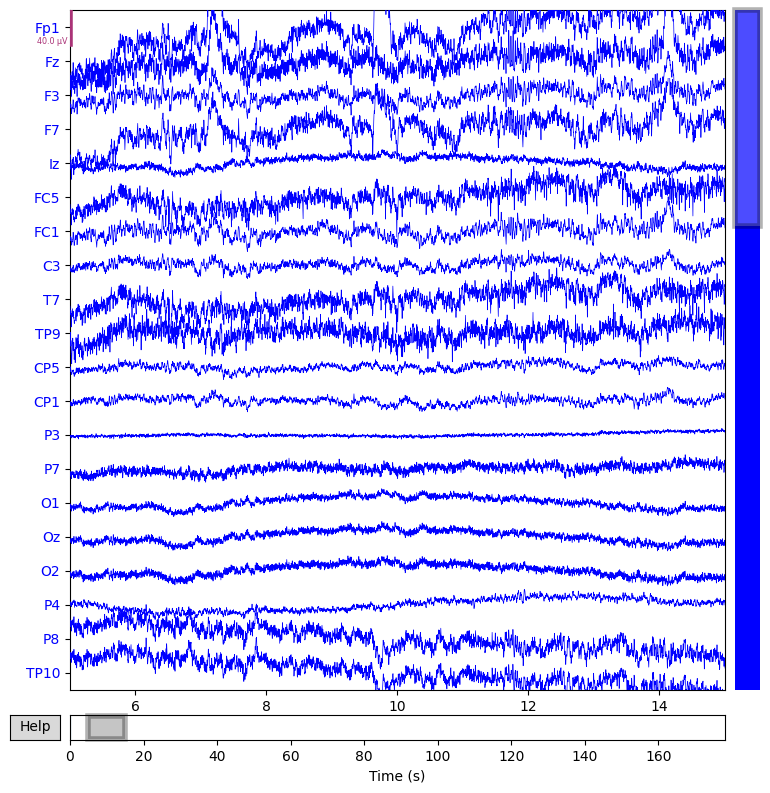

In [ ]:
## Plot the raw data
rawEegLab.plot(
    n_channels=20,
    color="blue",
    start=5,     # Starting at 5sec
    duration=10  # Plot 10sec long --> 5 ~ 5+10 sec
)
plt.show()

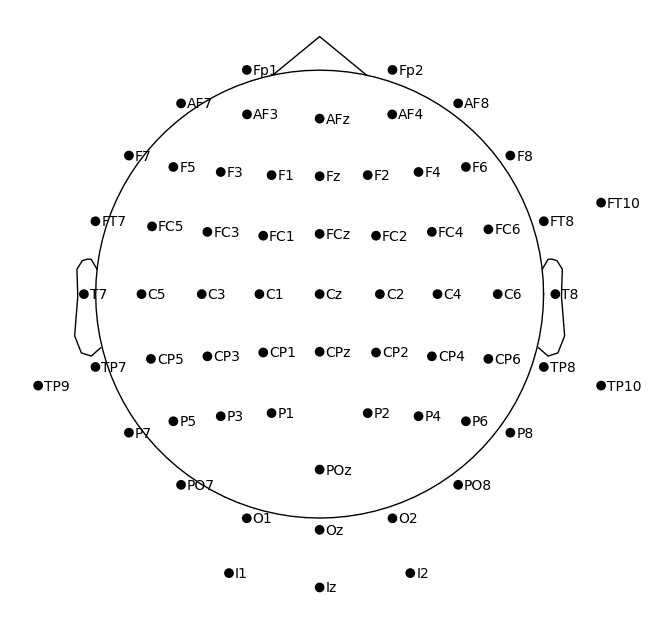

In [ ]:
## Plot the sensor names and location
rawEegLab.plot_sensors(show_names=True)
plt.show()

Effective window size : 4.096 (s)


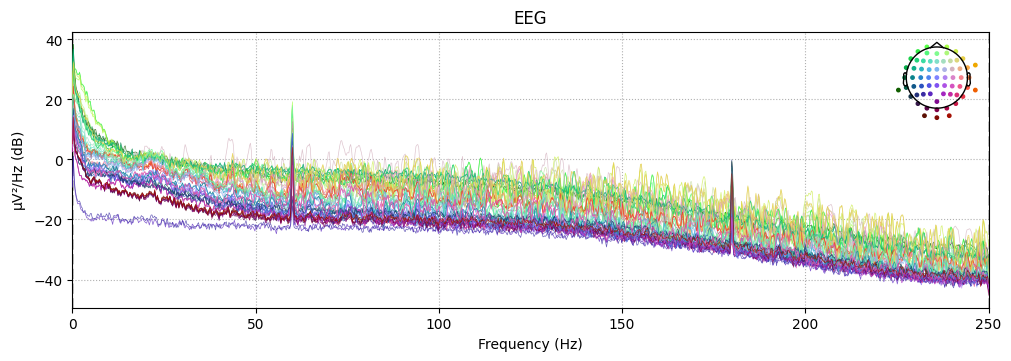

In [ ]:
## Plot the Power Spectral Density (PSD) in decibel
rawEegLab.compute_psd().plot(dB=True)
plt.show()